### Proyecto para clasificar tubérculos de papa basado en el estado de estas (buen estado y defectuoso)

Para ello se utilizará un modelo preentrenado **Vision Transformer (ViT-B16)**.

**Dataset Híbrido**: 36000 imágenes de papas clasificadas en dos categorías:

- ✅ Buen estado (calidad aceptable)
- ❌ Defectuoso (cortadas, con brotes, podridas)


### Importación de Librerías y configuraciones

Importamos las librerías necesarias para el procesamiento de imágenes, entrenamiento del modelo ViT y evaluación de resultados.


In [ ]:
%pip install torchmetrics torchvision grad-cam datasets huggingface_hub py7zr rarfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.3/495.3 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.2 MB/s eta 0:00:00
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=dacf088b1069f60a5f4caf58af36910e9a1aa6c8a5b7f41df856151a49316829
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import os, math, warnings
import shutil
from typing import Dict, Tuple, Callable, Optional, Any
from pathlib import Path
import numpy as np
import timm
import torch
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from dataclasses import dataclass
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
from timm.data import create_transform
import rarfile
import py7zr
import random

from torchvision import datasets, transforms
from google.colab import drive, userdata
from huggingface_hub import login, snapshot_download

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassF1Score,
    MulticlassRecall,
    MulticlassPrecision,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
)
from sklearn.model_selection import train_test_split

from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR

warnings.filterwarnings("ignore")

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", dispositivo)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    if torch.cuda.get_device_capability()[0] >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 habilitado")


# semilla
def configurar_semilla(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


configurar_semilla(42)

Dispositivo: cuda
GPU: Tesla T4


### Cargar Dataset

En esta sección se carga el dataset y se divide en un 80% para entrenamiento y un 20% para prueba. Posteriormente, dentro del conjunto de entrenamiento, se realiza una subdivisión del 80% para entrenamiento y el 20% restante para validación.


In [ ]:
# CONFIGURACION DE RUTAS E HIPERPARÁMETROS DE DATASET
# ===================================================

# ruta de division (train/val/test) y normalización (eliminar subcarpetas de lotes)
DIR_DATASET_DIVIDIDO = Path("/content/dataset_papas_dividido")
DIR_DATASET_NORMALIZADO = Path("/content/dataset_papas_normalizado")

# normalizar lotes para tener una estructura de clases completas sin subcarpetas de lotes.
# auto detecta estas estructuras por cada división o por dataset completo:
# - lote_clase: lote_1/Buen estado/img.jpg o train/lote_1/Buen estado/img.jpg
# - clase_lote: Buen estado/lote_1/img.jpg o train/Buen estado/lote_1/img.jpg
# Opciones: "auto", "lote_clase", "clase_lote".
NORMALIZAR_LOTES = True
ESTRUCTURA_LOTES = "auto"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp"}
SUBCONJUNTOS = ("train", "val", "test")

MEDIA = (0.485, 0.456, 0.406)
DESV_STD = (0.229, 0.224, 0.225)
SEMILLA = 42
TAMANIO_TEST = 0.2

# EXTRACCIÓN Y PREPARACIÓN DE DATASET
# ===================================
FORMATOS_COMPRIMIDOS = {
    ".zip",
    ".rar",
    ".7z",
    ".tar",
    ".tar.gz",
    ".tgz",
    ".tar.bz2",
    ".tbz2",
    ".tar.xz",
    ".txz",
}


# función para validar que una ruta de dataset exista y sea accesible
def validar_ruta_entrada_dataset(ruta: Path, nombre_origen: str) -> Path:
    ruta = Path(ruta)
    if ruta.exists():
        return ruta

    raise FileNotFoundError(
        f"No existe la ruta configurada para {nombre_origen}: {ruta}. "
        "Verifica que el archivo/carpeta exista antes de cargar el dataset."
    )


# función para montar Google Drive
def montar_drive_si_corresponde() -> None:
    if Path("/content/drive/MyDrive").exists():
        print("Drive ya esta montado.")
        return

    print("Montando Google Drive...")
    drive.mount("/content/drive")


# función para iniciar sesión en Hugging Face
def login_huggingface() -> None:
    token = userdata.get("HF_TOKEN")
    if token:
        login(token=token)
        print("Sesion de Hugging Face iniciada con HF_TOKEN.")
    else:
        print("HF_TOKEN no encontrado; se intentara descargar como dataset publico.")


# función para descargar dataset desde Hugging Face
def descargar_dataset_huggingface() -> Path:
    # Hugging Face: usa HF_TOKEN desde Secrets de Colab si el dataset es privado.
    dataset_repo = "Carlos012/dataset_papas"
    dataset_directorio_hf = ""
    dir_descarga_hf = Path("/content/dataset_papas_hf")
    login_huggingface()
    ruta_repo = Path(
        snapshot_download(
            repo_id=dataset_repo,
            repo_type="dataset",
            local_dir=dir_descarga_hf.as_posix(),
            allow_patterns=(
                f"{dataset_directorio_hf}/**" if dataset_directorio_hf else None
            ),
        )
    )

    ruta_dataset = (
        ruta_repo / dataset_directorio_hf if dataset_directorio_hf else ruta_repo
    )
    return validar_ruta_entrada_dataset(ruta_dataset, "Hugging Face")


# función para resolver la ruta del dataset
def resolver_ruta_dataset(origen: str, ruta_dataset: Path) -> Path:
    origen = origen.strip().lower()

    if origen == "huggingface":
        return descargar_dataset_huggingface()

    if origen == "drive":
        montar_drive_si_corresponde()
        return validar_ruta_entrada_dataset(ruta_dataset, "Google Drive")

    if origen == "local":
        return validar_ruta_entrada_dataset(ruta_dataset, "archivo local/subido")

    raise ValueError(
        f"Origen de dataset no permitido: {origen}. "
        "Usa 'huggingface', 'drive' o 'local'."
    )


# función para validar si un archivo es una imagen a partir de su extensión
def es_imagen(ruta: Path) -> bool:
    return ruta.is_file() and ruta.suffix.lower() in IMG_EXTS


# función para obtener la lista de clases desde un directorio raíz
def obtener_clases_desde(dir_raiz: Path) -> list[str]:
    if not dir_raiz.is_dir():
        return []

    return sorted(carpeta.name for carpeta in dir_raiz.iterdir() if carpeta.is_dir())


# función para contar el número total de imágenes en un directorio
def contar_imagenes(dir_raiz: Path) -> int:
    if not dir_raiz.is_dir():
        return 0

    return sum(1 for archivo in dir_raiz.rglob("*") if es_imagen(archivo))


# función para validar si el dataset ya está dividido en train/val/test con la misma estructura de clases en cada split
def validar_division(dir_raiz: Path) -> bool:
    dir_raiz = Path(dir_raiz)

    if not dir_raiz.is_dir():
        return False

    dir_division = {nombre: dir_raiz / nombre for nombre in SUBCONJUNTOS}

    # validar que existan las carpetas de división
    if not all(ruta.is_dir() for ruta in dir_division.values()):
        return False

    # obtener clases desde cada división
    clases_por_div = {
        nombre: obtener_clases_desde(ruta) for nombre, ruta in dir_division.items()
    }

    clases_train = clases_por_div["train"]

    if not clases_train:
        return False

    if not all(clases == clases_train for clases in clases_por_div.values()):
        return False

    for ruta_div in dir_division.values():
        for clase in clases_train:
            if contar_imagenes(ruta_div / clase) == 0:
                return False

    return True


# función para validar si el dataset tiene una estructura con subcarpetas de clases y al menos una imagen en cada clase
def validar_dataset(dir_raiz: Path) -> bool:
    dir_raiz = Path(dir_raiz)

    if not dir_raiz.is_dir():
        return False

    clases = [
        carpeta
        for carpeta in dir_raiz.iterdir()
        if carpeta.is_dir() and carpeta.name not in SUBCONJUNTOS
    ]

    return bool(clases) and all(contar_imagenes(clase) > 0 for clase in clases)


# función para extraer archivos comprimidos comunes
def obtener_extension_comprimida(ruta: Path) -> str:
    sufijos = [sufijo.lower() for sufijo in Path(ruta).suffixes]
    if len(sufijos) >= 2:
        extension_compuesta = "".join(sufijos[-2:])
        if extension_compuesta in FORMATOS_COMPRIMIDOS:
            return extension_compuesta

    return sufijos[-1] if sufijos else ""


# función para validar si una ruta es un archivo comprimido soportado
def es_archivo_comprimido(ruta: Path) -> bool:
    return (
        Path(ruta).is_file()
        and obtener_extension_comprimida(ruta) in FORMATOS_COMPRIMIDOS
    )


# función para resolver la raíz del dataset extraído
def resolver_raiz_extraida(dir_destino: Path) -> Path:
    carpetas = [carpeta for carpeta in dir_destino.iterdir() if carpeta.is_dir()]

    if len(carpetas) == 1:
        posible_raiz = carpetas[0]
        if validar_division(posible_raiz) or validar_dataset(posible_raiz):
            return posible_raiz

    return dir_destino


# función para extraer archivos comprimidos comunes a un directorio destino
def extraer_archivo_comprimido(ruta_archivo: Path, dir_destino: Path) -> Path:
    ruta_archivo = Path(ruta_archivo)
    dir_destino = Path(dir_destino)
    extension = obtener_extension_comprimida(ruta_archivo)

    if not ruta_archivo.is_file() or extension not in FORMATOS_COMPRIMIDOS:
        raise ValueError(
            f"Archivo comprimido con extensión no soportada: {ruta_archivo}"
        )

    dir_destino.mkdir(parents=True, exist_ok=True)

    if any(dir_destino.iterdir()):
        return resolver_raiz_extraida(dir_destino)

    if extension in {
        ".zip",
        ".tar",
        ".tar.gz",
        ".tgz",
        ".tar.bz2",
        ".tbz2",
        ".tar.xz",
        ".txz",
    }:
        shutil.unpack_archive(ruta_archivo, dir_destino)
    elif extension == ".7z":
        with py7zr.SevenZipFile(ruta_archivo, mode="r") as archivo_7z:
            archivo_7z.extractall(path=dir_destino)
    elif extension == ".rar":
        with rarfile.RarFile(ruta_archivo) as archivo_rar:
            archivo_rar.extractall(path=dir_destino)

    return resolver_raiz_extraida(dir_destino)


# función para obtener el nombre base de un archivo comprimido sin su extensión
def nombre_base_comprimido(ruta_archivo: Path) -> str:
    nombre = ruta_archivo.name
    extension = obtener_extension_comprimida(ruta_archivo)
    return nombre[: -len(extension)] if extension else ruta_archivo.stem


# función para extraer múltiples archivos comprimidos dentro de un directorio a un directorio destino
def extraer_comprimidos_de_directorio(dir_entrada: Path, dir_destino: Path) -> Path:
    dir_entrada = Path(dir_entrada)
    dir_destino = Path(dir_destino)
    archivos = sorted(
        archivo for archivo in dir_entrada.rglob("*") if es_archivo_comprimido(archivo)
    )

    if not archivos:
        return dir_entrada

    dir_destino.mkdir(parents=True, exist_ok=True)

    for archivo in archivos:
        nombre_lote = nombre_base_comprimido(archivo).replace(" ", "_")
        extraer_archivo_comprimido(archivo, dir_destino / nombre_lote)

    print(f"Archivos comprimidos extraidos desde {dir_entrada}: {len(archivos)}")
    return dir_destino


# función para preparar directorio de entrada: si es comprimido lo extrae; si es directorio lo retorna
def preparar_dir_entrada(dir_entrada: Path, dir_salida: Path) -> Path:
    dir_entrada = Path(dir_entrada)
    dir_salida = Path(dir_salida)

    if es_archivo_comprimido(dir_entrada):
        dir_extraccion = dir_salida.parent / f"{dir_salida.name}_completo"
        return extraer_archivo_comprimido(dir_entrada, dir_extraccion)

    if dir_entrada.is_dir():
        if contar_imagenes(dir_entrada) == 0:
            dir_extraccion = dir_salida.parent / f"{dir_salida.name}_archivos_extraidos"
            return extraer_comprimidos_de_directorio(dir_entrada, dir_extraccion)

        return dir_entrada

    formatos = ", ".join(sorted(FORMATOS_COMPRIMIDOS))
    raise ValueError(
        f"Entrada no valida: {dir_entrada}. Usa una carpeta o un archivo en: {formatos}"
    )


# función para consolidar datasets que vienen separados por lotes
def es_nombre_lote(nombre: str) -> bool:
    nombre = nombre.lower()
    pistas = ("lote", "batch", "part", "parte", "chunk", "shard", "bloque")
    return any(pista in nombre for pista in pistas)


# función para generar un nombre de archivo único
def nombre_archivo_unico(imagen: Path, dir_base: Path) -> str:
    partes = imagen.relative_to(dir_base).parts
    return "__".join(partes)


# función para copiar imágenes a una carpeta de clase destino
def copiar_imagenes_a_clase(
    imagenes: list[Path], dir_base: Path, dir_clase_destino: Path
) -> int:
    dir_clase_destino.mkdir(parents=True, exist_ok=True)
    copiadas = 0

    for imagen in imagenes:
        destino = dir_clase_destino / nombre_archivo_unico(imagen, dir_base)
        if not destino.exists():
            shutil.copy2(imagen, destino)
        copiadas += 1

    return copiadas


# función para resolver la estructura de lotes en un dataset a partir de su organización de carpetas e imágenes
def resolver_estructura_lotes(
    dir_base: Path, estructura: str = ESTRUCTURA_LOTES
) -> str:
    estructura = estructura.strip().lower()
    if estructura in {"lote_clase", "clase_lote"}:
        return estructura

    if estructura != "auto":
        raise ValueError(
            "ESTRUCTURA_LOTES debe ser 'auto', 'lote_clase' o 'clase_lote'."
        )

    carpetas = [carpeta for carpeta in dir_base.iterdir() if carpeta.is_dir()]
    if any(es_nombre_lote(carpeta.name) for carpeta in carpetas):
        return "lote_clase"

    nombres_hijos_por_carpeta = []
    for carpeta in carpetas:
        hijos_con_imagenes = {
            hijo.name
            for hijo in carpeta.iterdir()
            if hijo.is_dir() and contar_imagenes(hijo) > 0
        }
        if hijos_con_imagenes:
            nombres_hijos_por_carpeta.append(hijos_con_imagenes)

    if len(nombres_hijos_por_carpeta) >= 2:
        repetidos = set.intersection(*nombres_hijos_por_carpeta)
        if repetidos and not all(es_nombre_lote(nombre) for nombre in repetidos):
            return "lote_clase"

    return "clase_lote"


# función para organizar un dataset por clases
def consolidar_base_por_clase(
    dir_base: Path, dir_destino: Path, estructura: str = ESTRUCTURA_LOTES
) -> int:
    dir_base = Path(dir_base)
    dir_destino = Path(dir_destino)
    estructura = resolver_estructura_lotes(dir_base, estructura)
    print(f"Normalizando {dir_base} como estructura {estructura}.")
    total = 0

    if estructura == "lote_clase":
        for dir_lote in sorted(
            carpeta for carpeta in dir_base.iterdir() if carpeta.is_dir()
        ):
            for dir_clase in sorted(
                carpeta for carpeta in dir_lote.iterdir() if carpeta.is_dir()
            ):
                imagenes = sorted(
                    archivo for archivo in dir_clase.rglob("*") if es_imagen(archivo)
                )
                total += copiar_imagenes_a_clase(
                    imagenes=imagenes,
                    dir_base=dir_base,
                    dir_clase_destino=dir_destino / dir_clase.name,
                )
    else:
        for dir_clase in sorted(
            carpeta for carpeta in dir_base.iterdir() if carpeta.is_dir()
        ):
            if dir_clase.name in SUBCONJUNTOS:
                continue

            imagenes = sorted(
                archivo for archivo in dir_clase.rglob("*") if es_imagen(archivo)
            )
            total += copiar_imagenes_a_clase(
                imagenes=imagenes,
                dir_base=dir_base,
                dir_clase_destino=dir_destino / dir_clase.name,
            )

    return total


# función para normalizar datasets que vienen separados por lotes a una estructura de clases sin subcarpetas de lotes
def normalizar_lotes_dataset(dir_entrada: Path, dir_destino: Path) -> Path:
    dir_entrada = Path(dir_entrada)
    dir_destino = Path(dir_destino)

    if not NORMALIZAR_LOTES or not dir_entrada.is_dir():
        return dir_entrada

    if dir_destino.exists():
        shutil.rmtree(dir_destino)

    tiene_splits = all((dir_entrada / split).is_dir() for split in SUBCONJUNTOS)
    total = 0

    if tiene_splits:
        for split in SUBCONJUNTOS:
            total += consolidar_base_por_clase(
                dir_base=dir_entrada / split,
                dir_destino=dir_destino / split,
            )
    else:
        total = consolidar_base_por_clase(
            dir_base=dir_entrada,
            dir_destino=dir_destino,
        )

    if total == 0:
        return dir_entrada

    print(f"Dataset normalizado sin lotes: {dir_destino} ({total} imagenes)")
    return dir_destino


# función para dividir un dataset plano en train/val/test
def dividir_dataset(
    dir_origen: Path,
    dir_destino: Path,
    tamanio_test: float = 0.2,
    semilla: int = 42,
    limpiar_destino: bool = False,
):
    dir_origen = Path(dir_origen)
    dir_destino = Path(dir_destino)

    if not validar_dataset(dir_origen):
        raise ValueError(f"No se encontró un dataset válido en: {dir_origen}")

    # borrar datos de la división anterior para evitar mezclar datos antiguos con nuevos
    if limpiar_destino and dir_destino.exists():
        shutil.rmtree(dir_destino)

    dir_division = {nombre: dir_destino / nombre for nombre in SUBCONJUNTOS}

    for ruta in dir_division.values():
        ruta.mkdir(parents=True, exist_ok=True)

    clases = [
        carpeta.name
        for carpeta in dir_origen.iterdir()
        if carpeta.is_dir() and carpeta.name not in SUBCONJUNTOS
    ]

    for nombre_clase in clases:
        dir_clase = dir_origen / nombre_clase
        imagenes = [
            archivo.name for archivo in dir_clase.iterdir() if es_imagen(archivo)
        ]

        if len(imagenes) < 3:
            raise RuntimeError(
                f"La clase '{nombre_clase}' tiene muy pocas imágenes para dividir."
            )

        train_temp, test_imgs = train_test_split(
            imagenes,
            test_size=tamanio_test,
            random_state=semilla,
            shuffle=True,
        )

        train_imgs, val_imgs = train_test_split(
            train_temp,
            test_size=tamanio_test,
            random_state=semilla,
            shuffle=True,
        )

        imagenes_por_div = {
            "train": train_imgs,
            "val": val_imgs,
            "test": test_imgs,
        }

        for nombre_div, imgs_split in imagenes_por_div.items():
            clase_destino = dir_division[nombre_div] / nombre_clase
            clase_destino.mkdir(parents=True, exist_ok=True)

            for img in imgs_split:
                origen_img = dir_clase / img
                destino_img = clase_destino / img

                if not destino_img.exists():
                    shutil.copy2(origen_img, destino_img)

    return dir_division["train"], dir_division["val"], dir_division["test"]


# función para preparar dataset completo (train+val+test)
def preparar_dataset(
    dir_entrada: Path,
    dir_salida: Path,
    tamanio_test: float = 0.2,
    semilla: int = 42,
):
    dir_trabajo = preparar_dir_entrada(dir_entrada, dir_salida)
    dir_trabajo = normalizar_lotes_dataset(dir_trabajo, DIR_DATASET_NORMALIZADO)

    # valida si el dataset ya está dividido en dir_trabajo
    if validar_division(dir_trabajo):
        print(f"Dataset ya dividido: {dir_trabajo}")
        return dir_trabajo / "train", dir_trabajo / "val", dir_trabajo / "test"

    # valida si el dataset ya está dividido en dir_salida
    if validar_division(dir_salida):
        print(f"Utilizando dataset previamente dividido: {dir_salida}")
        return dir_salida / "train", dir_salida / "val", dir_salida / "test"

    # valida si es un dataset completo con subcarpetas de clases  y lo divide en dir_salida
    if validar_dataset(dir_trabajo):
        print(f"Dividiendo dataset desde: {dir_trabajo}")
        return dividir_dataset(
            dir_origen=dir_trabajo,
            dir_destino=dir_salida,
            tamanio_test=tamanio_test,
            semilla=semilla,
        )

    raise RuntimeError(f"No se encontró una estructura válida en: {dir_trabajo}")


# PREPARACIÓN DE DATASET
# =========================
# Ruta de dataset (Drive, Hugging Face o local). Puede ser un archivo comprimido o una carpeta con la estructura de clases (Buen estado, Defectuoso) o dividido en train/val/test
RUTA_DATASET = Path(
    "/content/drive/MyDrive/Datos_ViT/Datos/dataset_papas_hibrido_v2.zip"
)  # puede ser .rar, .zip, .7z.
# Origenes validos: "huggingface", "drive", "local".
ORIGEN_DATASET = "drive"

DATASET_COMPLETO = resolver_ruta_dataset(ORIGEN_DATASET, RUTA_DATASET)
print(f"Dataset de entrada resuelto: {DATASET_COMPLETO}")

train_dir, val_dir, test_dir = preparar_dataset(
    dir_entrada=DATASET_COMPLETO,
    dir_salida=DIR_DATASET_DIVIDIDO,
    tamanio_test=TAMANIO_TEST,
    semilla=SEMILLA,
)


# TRANSFORMACIONES VIT
# =========================
# auto_augment="rand-m9-mstd0.5-inc1" es una estrategia de aumento de datos aleatoria. -> SOLO PARA ENTRENAMIENTO
# re_prob=0.25 aplica el borrado aleatorio en el 25% de las imágenes.  -> SOLO PARA ENTRENAMIENTO
# re_mode="pixel" reemplaza una región aleatoria de la imágen por píxeles aleatorios. -> SOLO PARA ENTRENAMIENTO

transformaciones_vit_train = create_transform(
    input_size=(3, 224, 224),
    is_training=True,
    auto_augment="rand-m9-mstd0.5-inc1",
    re_prob=0.25,
    re_mode="pixel",
    mean=MEDIA,
    std=DESV_STD,
)

transformaciones_vit_eval = create_transform(
    input_size=(3, 224, 224),
    is_training=False,
    mean=MEDIA,
    std=DESV_STD,
)


# DATASETS Y DATALOADERS
# =========================
train_ds = datasets.ImageFolder(train_dir, transform=transformaciones_vit_train)
val_ds = datasets.ImageFolder(val_dir, transform=transformaciones_vit_eval)
test_ds = datasets.ImageFolder(test_dir, transform=transformaciones_vit_eval)

BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = dispositivo.type == "cuda"

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)


# INFORMACIÓN DE DATASET
# =========================
total = len(train_ds) + len(val_ds) + len(test_ds)

print("Clases:", train_ds.classes)
print(f"Datos totales: {total} -> 100%")
print(
    f"Train: {len(train_ds)} ({len(train_ds) / total * 100:.2f}%) | "
    f"Val: {len(val_ds)} ({len(val_ds) / total * 100:.2f}%) | "
    f"Test: {len(test_ds)} ({len(test_ds) / total * 100:.2f}%)"
)

Montando Google Drive...
Mounted at /content/drive
Dataset de entrada resuelto: /content/drive/MyDrive/Datos_ViT/Datos/dataset_papas_hibrido_v2.zip
Normalizando /content/dataset_papas_dividido_completo/train como estructura clase_lote.
Normalizando /content/dataset_papas_dividido_completo/val como estructura clase_lote.
Normalizando /content/dataset_papas_dividido_completo/test como estructura clase_lote.
Dataset normalizado sin lotes: /content/dataset_papas_normalizado (36000 imagenes)
Dataset ya dividido: /content/dataset_papas_normalizado
Clases: ['Buen estado', 'Defectuoso']
Datos totales: 36000 -> 100%
Train: 23040 (64.00%) | Val: 5760 (16.00%) | Test: 7200 (20.00%)


### Configuración del Modelo ViT (Transfer Learning)

Cargamos **Vision Transformer Base (ViT-Base/16)** con pesos preentrenados de ImageNet-1K.

**Estrategia de Transfer Learning**:

- Congelamos el backbone completo (embeddings + encoder)
- Solo entrenamos la cabeza clasificadora (2 clases: buen estado, defectuoso)
- Resultado: ~1,538 parámetros entrenables vs ~85M congelados


In [ ]:
"""
num_clases (int): número de clases de salida.
capas_descongelar (int): número de capas del backbone a descongelar.
    - 0: modelo base (solo la cabeza entrenable).
    - 1: transfer learning mínimo (última capa).
    - 6: fine-tuning parcial.
    - 12: fine-tuning total.
"""


class ClasificadorPapasViT(nn.Module):
    def __init__(self, num_clases: int = 2, capas_descongelar: int = 0):

        super().__init__()

        # crear modelo ViT base con pesos preentrenados
        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=num_clases,
        )

        # inicializar explícitamente la nueva cabeza de clasificación
        nn.init.xavier_uniform_(
            self.backbone.head.weight
        )  # pesos con distribución estable
        nn.init.zeros_(self.backbone.head.bias)  # sesgos en cero

        # congelar todo el backbone excepto la cabeza
        for name, p in self.backbone.named_parameters():
            if "head" not in name:
                p.requires_grad = False

        # descongelar las últimas N capas si se especifica
        if capas_descongelar > 0:
            encoder_layers = list(self.backbone.blocks)  # bloques del encoder ViT
            # Seleccionamos las últimas N capas y las hacemos entrenables
            for layer in encoder_layers[-capas_descongelar:]:
                for p in layer.parameters():
                    p.requires_grad = True

    def forward(self, valores_pixel: torch.Tensor) -> torch.Tensor:
        # forward directo al backbone
        return self.backbone(valores_pixel)


# crear modelo para Transfer Learning
modelo = ClasificadorPapasViT(num_clases=2, capas_descongelar=0).to(dispositivo)

# parámetros entrenables
entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
total = sum(p.numel() for p in modelo.parameters())
print(
    f"Parámetros entrenables: {entrenables:,} / {total:,} ({100*entrenables/total:.4f}%)"
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Parámetros entrenables: 1,538 / 85,800,194 (0.0018%)


### Configuración de hiperparámetros

---

En esta sección se configuran los hiperparámetros necesarios para que el modelo aprenda de manera óptima y logre una convergencia más rápida y eficiente, utilizando optimizadores como AdamW. Los hiperparámetros definidos son:

- Número de épocas.
- Tasa de aprendizaje (learning rate).
- Weight Decay o regularización de pesos.
- Parámetros Beta (B1 y B2).
- Uso de precisión mixta según el dispositivo disponible.


In [ ]:
# configuración de hiperparámetros para entrenamiento.
@dataclass
class ConfigEntrenamiento:
    epocas: int = 30
    lr: float = 1e-5
    weight_decay: float = 1e-4
    batch_size: int = 32
    warmup_frac: float = 0.5
    betas: Tuple[float, float] = (0.9, 0.999)
    mixed_precision: bool = True
    metrica_principal: str = "f1"

    def __str__(self):
        return (
            f"Configuración:\n"
            f"Épocas: {self.epocas}\n"
            f"Learning Rate: {self.lr}\n"
            f"Weight Decay: {self.weight_decay}\n"
            f"Batch Size: {self.batch_size}\n"
            f"Mixed Precision: {self.mixed_precision}\n"
            f"Betas: {self.betas}\n"
            f"Warmup Frac: {self.warmup_frac}\n"
            f"Métrica Principal: {self.metrica_principal}\n"
        )

### Configuración de Entrenamiento

---

Definimos hiperparámetros y objetos necesarios para el entrenamiento:

- **Optimizador**: AdamW con weight decay para regularización
- **programador**: Linear con warmup (50% de los pasos)
- **Mixed Precision**: AMP (Precisión Mixta Automática) para eficiencia en GPU
- **Métricas**: Accuracy, Recall, Precision y F1-Score con torchmetrics


In [ ]:
# criterio_perdida de pérdida
criterio_perdida = nn.CrossEntropyLoss()
# configuración
config = ConfigEntrenamiento()
# mostrar configuración
display(config)
# programador con warmup lineal
pasos_totales = config.epocas * max(1, len(train_loader))
warmup_pasos = int(config.warmup_frac * pasos_totales)
# optimizador
optimizador = optim.AdamW(
    [p for p in modelo.parameters() if p.requires_grad],
    lr=config.lr,
    betas=config.betas,
    weight_decay=config.weight_decay,
)


# lambda para que el programador ajuste el LR con warmup lineal
def lr_lambda(paso):
    if paso < warmup_pasos:
        return float(paso) / float(max(1, warmup_pasos))
    return max(
        0.0, float(pasos_totales - paso) / float(max(1, pasos_totales - warmup_pasos))
    )


programador = LambdaLR(optimizador, lr_lambda)

# GradScaler para precisión mixta y mejor rendimiento
escala = GradScaler(enabled=config.mixed_precision)

# métricas con torchmetrics
num_clases = 2
acc_metrica = MulticlassAccuracy(num_classes=num_clases, average="weighted").to(
    dispositivo
)
f1_metrica = MulticlassF1Score(num_classes=num_clases, average="weighted").to(
    dispositivo
)
recall_metrica = MulticlassRecall(num_classes=num_clases, average="weighted").to(
    dispositivo
)
precision_metrica = MulticlassPrecision(num_classes=num_clases, average="weighted").to(
    dispositivo
)

# checkpoint dirección
CHECKPOINT_TL = Path(
    "/content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt"
)
CHECKPOINT_FTP = Path(
    "/content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt"
)
CHECKPOINT_TL.parent.mkdir(parents=True, exist_ok=True)
CHECKPOINT_FTP.parent.mkdir(parents=True, exist_ok=True)
print(f"\nCheckpoint Transfer Learning se guardará en: {CHECKPOINT_TL.as_posix()}")
print(f"Checkpoint Fine-Tuning se guardará en: {CHECKPOINT_FTP.as_posix()}")
print(f"Pasos totales: {pasos_totales} (warmup: {warmup_pasos} pasos)")

ConfigEntrenamiento(epocas=30, lr=1e-05, weight_decay=0.0001, batch_size=32, warmup_frac=0.5, betas=(0.9, 0.999), mixed_precision=True, metrica_principal='f1')


Checkpoint se guardará en: /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
Checkpoint Fine-Tuning se guardará en: /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
Pasos totales: 21600 (warmup: 10800 pasos)


In [ ]:
# crear diccionario con métricas de clasificación
def crear_metricas(
    num_clases: int = 2, dispositivo: torch.device = torch.device("cpu")
) -> Dict[str, Any]:
    return {
        "acc": MulticlassAccuracy(num_classes=num_clases, average="weighted").to(
            dispositivo
        ),
        "f1": MulticlassF1Score(num_classes=num_clases, average="weighted").to(
            dispositivo
        ),
        "precision": MulticlassPrecision(num_classes=num_clases, average="weighted").to(
            dispositivo
        ),
        "recall": MulticlassRecall(num_classes=num_clases, average="weighted").to(
            dispositivo
        ),
    }

### Entrenar capas de clasificación - Transfer Learning

---

En esta sección se reentrena la capa final de clasificación del modelo ViT-Base/16 mediante la técnica de Transfer Learning, utilizando los conjuntos de entrenamiento y validación previamente separados. Durante el proceso de reentrenamiento se calcula la función de pérdida y la precisión en cada época, y con base en estos resultados se actualiza y guarda el mejor modelo alcanzado.


In [ ]:
import pandas as pd
from tqdm import tqdm


def iterar_epoca(
    modelo: nn.Module,
    loader: DataLoader,
    criterio_perdida: nn.Module,
    metricas: Dict[str, Any],
    dispositivo: torch.device,
    optimizador: Optional[optim.Optimizer],
    escala: Optional[GradScaler] = None,
    programador: Optional[LambdaLR] = None,
    entrenar: bool = True,
    mixed_precision: bool = True,
) -> Dict[str, float]:

    modelo.train(mode=entrenar)
    # reset métricas
    for metrica in metricas.values():
        metrica.reset()
    perdidas = []
    descripcion = "Train" if entrenar else "Val"

    for batch in tqdm(loader, leave=False, desc=descripcion):
        imagenes, etiquetas = batch[0].to(dispositivo, non_blocking=True), batch[1].to(
            dispositivo, non_blocking=True
        )

        with torch.set_grad_enabled(entrenar):
            with autocast(enabled=mixed_precision):
                salida = modelo(valores_pixel=imagenes)
                perdida = criterio_perdida(salida, etiquetas)

            if entrenar:
                optimizador.zero_grad(set_to_none=True)
                escala.scale(perdida).backward()
                escala.step(optimizador)
                escala.update()
                # verificar si programador no es None para evitar error
                if programador is not None:
                    programador.step()

        perdidas.append(perdida.detach().item())
        predicciones = salida.detach().argmax(dim=1)

        # actualizar métricas
        for metrica in metricas.values():
            metrica.update(predicciones, etiquetas)

    # calcular métricas finales
    resultados = {
        "perdida": float(np.mean(perdidas)) if perdidas else math.nan,
    }
    for nombre, metrica in metricas.items():
        resultados[nombre] = float(metrica.compute().item())
    return resultados


# metodo de entrenamiento
def entrenar_modelo(
    modelo: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterio_perdida: nn.Module,
    optimizador: optim.Optimizer,
    metricas: Dict[str, Any],
    config: ConfigEntrenamiento,
    ruta_ckpt: Path,
    dispositivo: torch.device,
    programador: Optional[LambdaLR] = None,
    escala: Optional[GradScaler] = None,
    callback_epoca: Optional[Callable] = None,
    descripcion: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    mejor_metrica = -1.0
    mejor_epoca = -1
    mejor_perdida = float("inf")
    historia = []

    if descripcion:
        print("Iniciando entrenamiento...\n")
        print("=====" * 20)
        print(config)
        print(f"Metrica principal {config.metrica_principal}\n")
        print(f"Ruta checkpoint: {ruta_ckpt.as_posix()}\n")
        print("=====" * 20)
    for epoca in range(1, config.epocas + 1):
        # entrenamiento
        metricas_train = iterar_epoca(
            modelo,
            train_loader,
            criterio_perdida,
            metricas,
            dispositivo,
            optimizador,
            escala,
            programador,
            entrenar=True,
            mixed_precision=config.mixed_precision,
        )
        # validación
        metricas_val = iterar_epoca(
            modelo=modelo,
            loader=val_loader,
            optimizador=None,
            criterio_perdida=criterio_perdida,
            metricas=metricas,
            dispositivo=dispositivo,
            entrenar=False,
            mixed_precision=config.mixed_precision,
        )
        # registrar historia
        registro = {"epoca": epoca}
        for nombre, valor in metricas_train.items():
            registro[f"train_{nombre}"] = valor
        for nombre, valor in metricas_val.items():
            registro[f"val_{nombre}"] = valor
        historia.append(registro)

        # callback por época
        if callback_epoca:
            callback_epoca(epoca, metricas_train, metricas_val)
        # imprimir resultados
        if descripcion:
            print(f"Época {epoca:02d}/{config.epocas} | ")
            print(
                f"Train → {' | '.join([f'{k}: {v:.4f}' for k, v in metricas_train.items()])}"
            )
            print(
                f"Val → {' | '.join([f'{k}: {v:.4f}' for k, v in metricas_val.items()])}"
            )
        # guardar mejor modelo
        metrica_actual = metricas_val[config.metrica_principal]
        perdida_actual = metricas_val["perdida"]
        mejorado = False
        if config.metrica_principal == "perdida":
            if perdida_actual < mejor_perdida:
                mejorado = True
        else:
            if (metrica_actual > mejor_metrica) or (
                metrica_actual == mejor_metrica and perdida_actual < mejor_perdida
            ):
                mejorado = True

        if mejorado:
            mejor_metrica = metrica_actual
            mejor_epoca = epoca
            mejor_perdida = perdida_actual
            # guardar checkpoint completo
            torch.save(
                {
                    "epoca": epoca,
                    "modelo_state_dict": modelo.state_dict(),
                    "optimizador_state_dict": optimizador.state_dict(),
                    "mejor_metrica": mejor_metrica,
                    "mejor_perdida": mejor_perdida,
                    "metricas_train": metricas_train,
                    "metricas_val": metricas_val,
                },
                ruta_ckpt,
            )
            # guardar solo pesos del modelo
            ruta_pesos = ruta_ckpt.with_name(ruta_ckpt.stem + "_pesos.pt")
            torch.save(modelo.state_dict(), ruta_pesos)
        if descripcion:
            if mejorado:
                print(
                    f"✓ Mejor modelo guardado (época {epoca}) → {ruta_ckpt.as_posix()}"
                )
                print(f"F1-Score: {mejor_metrica:.4f}")
            print("-----" * 20)
    if descripcion:
        print("Entrenamiento finalizado.")
        print(f"{'====='*20}")
        print(
            f"Mejor {config.metrica_principal}: {mejor_metrica:.4f} (época {mejor_epoca})"
        )
        print(f"Mejor pérdida: {mejor_perdida:.6f}")
        print(f"{'====='*20}\n")

    # crear DataFrame de historia
    df_historia = pd.DataFrame(historia)
    mejores_metricas = {
        "epoca": mejor_epoca,
        config.metrica_principal: mejor_metrica,
        "perdida": mejor_perdida,
    }

    return df_historia, mejores_metricas


# ================================================
# configuración de ENTRENAMIENTO TRANSFER LEARNING
# ================================================
config_tlr = ConfigEntrenamiento(
    epocas=30,
    lr=1e-5,
    weight_decay=1e-2,
    batch_size=BATCH_SIZE,
    warmup_frac=0.5,
    mixed_precision=True,
    metrica_principal="f1",
)

# crear métricas
metricas = crear_metricas(num_clases=2, dispositivo=dispositivo)

# entrenar modelo
historia_tl, mejores_metricas_tl = entrenar_modelo(
    modelo=modelo,
    train_loader=train_loader,
    val_loader=val_loader,
    criterio_perdida=criterio_perdida,
    optimizador=optimizador,
    metricas=metricas,
    config=config_tlr,
    ruta_ckpt=CHECKPOINT_TL,
    dispositivo=dispositivo,
    programador=programador,
    escala=escala,
    descripcion=True,
)

# mostrar métricas
display(historia_tl)

Iniciando entrenamiento...

Configuración:
Épocas: 30
Learning Rate: 1e-05
Weight Decay: 0.01
Batch Size: 32
Mixed Precision: True
Betas: (0.9, 0.999)
Warmup Frac: 0.5
Métrica Principal: f1

Metrica principal f1

Ruta checkpoint: /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt



Época 01/30 | 
Train → perdida: 1.0074 | acc: 0.4956 | f1: 0.4956 | precision: 0.4956 | recall: 0.4956
Val → perdida: 1.0348 | acc: 0.4476 | f1: 0.4472 | precision: 0.4474 | recall: 0.4476
✓ Mejor modelo guardado (época 1) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.4472
----------------------------------------------------------------------------------------------------


Época 02/30 | 
Train → perdida: 0.9834 | acc: 0.5075 | f1: 0.5075 | precision: 0.5075 | recall: 0.5075
Val → perdida: 0.9913 | acc: 0.4658 | f1: 0.4650 | precision: 0.4656 | recall: 0.4658
✓ Mejor modelo guardado (época 2) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.4650
----------------------------------------------------------------------------------------------------


Época 03/30 | 
Train → perdida: 0.9334 | acc: 0.5267 | f1: 0.5267 | precision: 0.5267 | recall: 0.5267
Val → perdida: 0.9253 | acc: 0.5012 | f1: 0.4996 | precision: 0.5012 | recall: 0.5012
✓ Mejor modelo guardado (época 3) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.4996
----------------------------------------------------------------------------------------------------


Época 04/30 | 
Train → perdida: 0.8700 | acc: 0.5557 | f1: 0.5554 | precision: 0.5559 | recall: 0.5557
Val → perdida: 0.8414 | acc: 0.5377 | f1: 0.5360 | precision: 0.5382 | recall: 0.5377
✓ Mejor modelo guardado (época 4) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.5360
----------------------------------------------------------------------------------------------------


...

Época 27/30 | 
Train → perdida: 0.2613 | acc: 0.8918 | f1: 0.8917 | precision: 0.8919 | recall: 0.8918
Val → perdida: 0.1491 | acc: 0.9526 | f1: 0.9526 | precision: 0.9528 | recall: 0.9526
✓ Mejor modelo guardado (época 27) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.9526
----------------------------------------------------------------------------------------------------


Época 28/30 | 
Train → perdida: 0.2662 | acc: 0.8888 | f1: 0.8888 | precision: 0.8889 | recall: 0.8888
Val → perdida: 0.1481 | acc: 0.9531 | f1: 0.9531 | precision: 0.9534 | recall: 0.9531
✓ Mejor modelo guardado (época 28) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.9531
----------------------------------------------------------------------------------------------------


Época 29/30 | 
Train → perdida: 0.2611 | acc: 0.8941 | f1: 0.8940 | precision: 0.8941 | recall: 0.8941
Val → perdida: 0.1474 | acc: 0.9533 | f1: 0.9533 | precision: 0.9535 | recall: 0.9533
✓ Mejor modelo guardado (época 29) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.9533
----------------------------------------------------------------------------------------------------


Época 30/30 | 
Train → perdida: 0.2634 | acc: 0.8924 | f1: 0.8924 | precision: 0.8927 | recall: 0.8924
Val → perdida: 0.1472 | acc: 0.9535 | f1: 0.9535 | precision: 0.9537 | recall: 0.9535
✓ Mejor modelo guardado (época 30) → /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
F1-Score: 0.9535
----------------------------------------------------------------------------------------------------
Entrenamiento finalizado.
Mejor f1: 0.9535 (época 30)
Mejor pérdida: 0.147179



,epoca,train_perdida,train_acc,train_f1,train_precision,train_recall,val_perdida,val_acc,val_f1,val_precision,val_recall
0,1,1.007446,0.495616,0.495583,0.495615,0.495616,1.034810,0.447569,0.447224,0.447438,0.447569
1,2,0.983422,0.507509,0.507468,0.507511,0.507509,0.991300,0.465799,0.464997,0.465592,0.465799
2,3,0.933367,0.526736,0.526683,0.526748,0.526736,0.925264,0.501215,0.499583,0.501231,0.501215
3,4,0.870029,0.555729,0.555360,0.555915,0.555729,0.841356,0.537674,0.536009,0.538222,0.537674
4,5,0.798035,0.591493,0.591280,0.591684,0.591493,0.751987,0.588021,0.586191,0.589606,0.588021
5,6,0.727575,0.632726,0.632584,0.632930,0.632726,0.663759,0.642882,0.640814,0.646249,0.642882
6,7,0.663414,0.669792,0.669543,0.670304,0.669792,0.581096,0.697569,0.696343,0.700813,0.697569
7,8,0.592124,0.714800,0.714519,0.715650,0.714800,0.507700,0.749306,0.748289,0.753398,0.749306
8,9,0.542749,0.746875,0.746707,0.747533,0.746875,0.444280,0.789236,0.788363,0.794090,0.789236
9,10,0.492358,0.776476,0.776345,0.777126,0.776476,0.389119,0.826389,0.826001,0.829326,0.826389


### Prueba del mejor modelo - Transfer Learning

---

En esta sección se evalúa el mejor modelo obtenido durante el entrenamiento, calculando las métricas de pérdida, precisión y F1-Score para medir su rendimiento final.


In [ ]:
# cargar mejor checkpoint
def cargar_checkpoint(
    modelo: nn.Module,
    ruta_checkpoint: Path,
    dispositivo: torch.device = torch.device("cpu"),
) -> nn.Module:
    checkpoint = torch.load(
        ruta_checkpoint, map_location=dispositivo, weights_only=False
    )

    # detectar si las claves tienen el prefijo "_orig_mod."
    state_dict = checkpoint["modelo_state_dict"]
    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        # limpiar el prefijo
        new_state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
        modelo.load_state_dict(new_state_dict, strict=False)
    else:
        modelo.load_state_dict(state_dict)

    print(f"Checkpoint cargado: {ruta_checkpoint}")
    if "epoca" in checkpoint:
        print(f"Época: {checkpoint['epoca']}")
        if "mejor_metrica" in checkpoint:
            print(f"   Mejor métrica: {checkpoint['mejor_metrica']:.4f}")

    return modelo


# instaciar modelo base
modelo_base = ClasificadorPapasViT(num_clases=2, capas_descongelar=0).to(dispositivo)
# cargar modelo entrenado
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_TL)


# evaluación en test
def evaluar_modelo(
    modelo: nn.Module,
    test_loader: DataLoader,
    criterio_perdida: nn.Module,
    metricas: Dict[str, Any],
    dispositivo: torch.device,
    clases: list,
    mixed_precision: bool = False,
    detallado: bool = True,
) -> Tuple[Dict[str, float], list, list]:

    modelo.eval()

    # resetear métricas
    for metrica in metricas.values():
        metrica.reset()

    perdidas = []
    y_true, y_pred = [], []

    with torch.no_grad(), autocast(enabled=mixed_precision):
        for batch in tqdm(test_loader, desc="Test", leave=False):
            imagenes, etiquetas = batch[0].to(dispositivo, non_blocking=True), batch[
                1
            ].to(dispositivo, non_blocking=True)
            salida = modelo(valores_pixel=imagenes)
            perdida = criterio_perdida(salida, etiquetas)

            perdidas.append(perdida.item())
            predicciones = salida.argmax(dim=1)

            for metrica in metricas.values():
                metrica.update(predicciones, etiquetas)

            y_pred.extend(predicciones.cpu().tolist())
            y_true.extend(etiquetas.cpu().tolist())

    # calcular métricas
    resultados = {"perdida": float(np.mean(perdidas))}
    for nombre, metrica in metricas.items():
        resultados[nombre] = float(metrica.compute().item())

    if detallado:
        print(f"\n{'===='*20}")
        print("RESULTADOS EN TEST")
        print(f"{'===='*20}")
        for nombre, valor in resultados.items():
            print(f"{nombre.capitalize()}: {valor:.4f}")
        print(f"{'===='*20}\n")

        print("Reporte de Clasificación:")
        print(classification_report(y_true, y_pred, target_names=clases))

    return resultados, y_true, y_pred


def contar_imagenes_por_clase(dir_raiz: Path) -> Dict[str, int]:
    return {
        clase: contar_imagenes(dir_raiz / clase)
        for clase in obtener_clases_desde(dir_raiz)
    }


def validar_dataset_prueba(dir_prueba: Path, clases_referencia: list[str]) -> None:
    dir_prueba = Path(dir_prueba)

    if not validar_dataset(dir_prueba):
        raise ValueError(f"Dataset de prueba no válido: {dir_prueba}")

    clases_prueba = obtener_clases_desde(dir_prueba)
    if clases_prueba != clases_referencia:
        raise ValueError(
            f"Clases incompatibles. Esperadas: {clases_referencia}; recibidas: {clases_prueba}"
        )


def crear_test_desde_dataset_completo(
    dir_origen: Path,
    dir_destino: Path,
    conteo_referencia: Dict[str, int],
    semilla: int = SEMILLA,
) -> Path:
    if dir_destino.exists():
        shutil.rmtree(dir_destino)

    rng = np.random.default_rng(semilla)
    dir_destino.mkdir(parents=True, exist_ok=True)

    for clase, cantidad in conteo_referencia.items():
        dir_clase_origen = dir_origen / clase
        dir_clase_destino = dir_destino / clase
        imagenes = sorted(
            archivo for archivo in dir_clase_origen.iterdir() if es_imagen(archivo)
        )

        if len(imagenes) < cantidad:
            raise ValueError(
                f"La clase '{clase}' tiene {len(imagenes)} imagenes; se requieren {cantidad}."
            )

        seleccionadas = rng.choice(imagenes, size=cantidad, replace=False)
        dir_clase_destino.mkdir(parents=True, exist_ok=True)

        for imagen in seleccionadas:
            shutil.copy2(imagen, dir_clase_destino / imagen.name)

    return dir_destino


# función para resolver el directorio de prueba a usar según la ruta proporcionada por el usuario
def resolver_directorio_prueba(
    ruta_dataset_prueba: Optional[Path],
    dir_prueba_temporal: Path = Path("/content/dataset_prueba_externo"),
    dir_prueba_completo: Path = Path("/content/dataset_prueba_externo_dividido/test"),
) -> Path:
    if ruta_dataset_prueba is None:
        return test_dir

    dir_trabajo = preparar_dir_entrada(ruta_dataset_prueba, dir_prueba_temporal)

    # si tiene train/val/test, se toma solo test.
    if validar_division(dir_trabajo):
        return dir_trabajo / "test"

    # si es completo, se crea un test con el mismo conteo por clase del test principal.
    if validar_dataset(dir_trabajo):
        validar_dataset_prueba(dir_trabajo, train_ds.classes)
        conteo_referencia = contar_imagenes_por_clase(test_dir)
        return crear_test_desde_dataset_completo(
            dir_origen=dir_trabajo,
            dir_destino=dir_prueba_completo,
            conteo_referencia=conteo_referencia,
        )

    raise ValueError(f"Dataset de prueba no valido: {dir_trabajo}")


def crear_loader_prueba(dir_prueba: Path) -> DataLoader:
    validar_dataset_prueba(dir_prueba, train_ds.classes)
    test_dataset = datasets.ImageFolder(dir_prueba, transform=transformaciones_vit_eval)

    loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    print(
        f"Datos de prueba cargados: {len(test_dataset)} imagenes en {len(test_dataset.classes)} clases"
    )
    print(f"Clases: {test_dataset.classes}")
    return loader


def cargar_datos_prueba(
    test_loader=None,
    ruta_dataset_prueba: Optional[Path] = None,
):
    # si no existe ruta de dataset de prueba se usa el test_loader predefinido
    if ruta_dataset_prueba is None and test_loader is not None:
        return test_loader

    dir_prueba = resolver_directorio_prueba(ruta_dataset_prueba)
    return crear_loader_prueba(dir_prueba)


# ruta dataset de prueba externo
RUTA_DATASET_PRUEBA = None

# evaluar el modelo en test
metricas_test_tl, y_true_tl, y_pred_tl = evaluar_modelo(
    modelo=modelo,
    test_loader=cargar_datos_prueba(test_loader, RUTA_DATASET_PRUEBA),
    criterio_perdida=criterio_perdida,
    metricas=metricas,
    dispositivo=dispositivo,
    clases=train_ds.classes,
    mixed_precision=config_tlr.mixed_precision,
    detallado=True,
)

mcc = matthews_corrcoef(y_true_tl, y_pred_tl)
print(f"MCC: {mcc:.4f}")

df_test_tl = pd.DataFrame([{f"test_{k}": v for k, v in metricas_test_tl.items()}])
df_test_tl["test_mcc"] = mcc
display(df_test_tl)

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.9535



RESULTADOS EN TEST
Perdida: 0.1472
Acc: 0.9533
F1: 0.9533
Precision: 0.9535
Recall: 0.9533

Reporte de Clasificación:
              precision    recall  f1-score   support

 Buen estado       0.96      0.94      0.95      3600
  Defectuoso       0.94      0.96      0.95      3600

    accuracy                           0.95      7200
   macro avg       0.95      0.95      0.95      7200
weighted avg       0.95      0.95      0.95      7200



,test_perdida,test_acc,test_f1,test_precision,test_recall
0,0.147225,0.953333,0.953329,0.953515,0.953333


### Gráficas analíticas

---

En esta sección se presentan las gráficas de pérdida correspondientes al entrenamiento, validación y prueba, con el objetivo de mostrar la evolución del modelo y analizar su desempeño en términos de Precisión y F1-Score durante la fase de Transfer Learning.


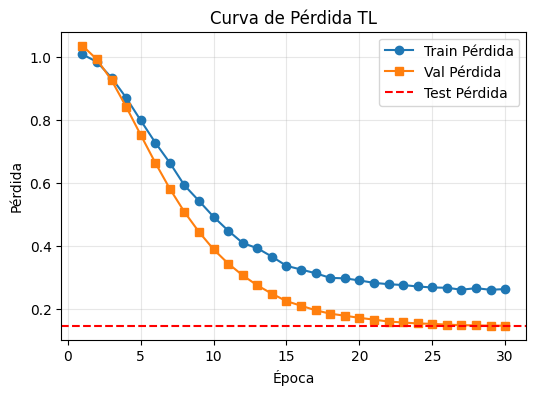

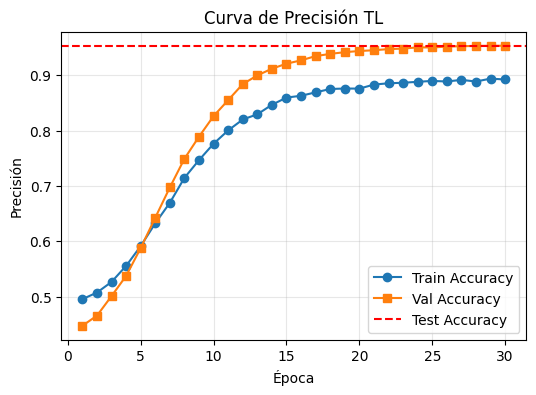

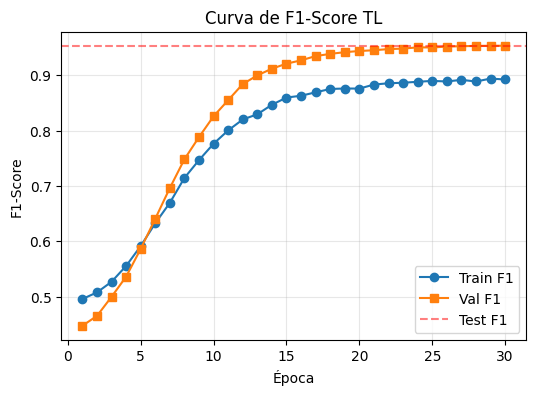

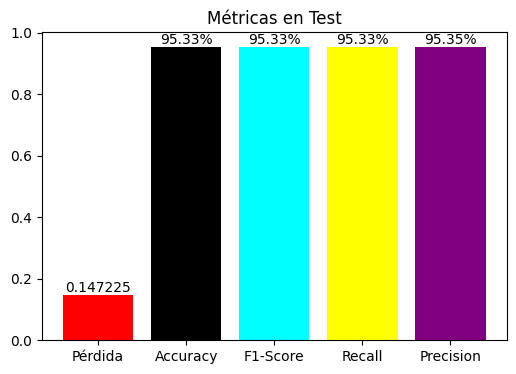

In [ ]:
# asegurar que 'epoca' sea numérica
historia_tl["epoca"] = pd.to_numeric(historia_tl["epoca"], errors="coerce")
historia_tl = historia_tl.dropna(subset=["epoca"])

# gráfica de Pérdida (Train, Val, Test)
plt.figure(figsize=(6, 4))
plt.plot(
    historia_tl.epoca, historia_tl.train_perdida, label="Train Pérdida", marker="o"
)
plt.plot(historia_tl.epoca, historia_tl.val_perdida, label="Val Pérdida", marker="s")
# línea horizontal para test
plt.axhline(
    y=df_test_tl.test_perdida.iloc[0], color="red", linestyle="--", label="Test Pérdida"
)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de Pérdida TL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# gráfica de Accuracy (Train, Val, Test)
plt.figure(figsize=(6, 4))
plt.plot(historia_tl.epoca, historia_tl.train_acc, label="Train Accuracy", marker="o")
plt.plot(historia_tl.epoca, historia_tl.val_acc, label="Val Accuracy", marker="s")
# línea horizontal para test
plt.axhline(
    y=df_test_tl.test_acc.iloc[0], color="red", linestyle="--", label="Test Accuracy"
)
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.title("Curva de Precisión TL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# gráfica de F1-Score (Train, Val, Test)
plt.figure(figsize=(6, 4))
plt.plot(historia_tl.epoca, historia_tl.train_f1, label="Train F1", marker="o")
plt.plot(historia_tl.epoca, historia_tl.val_f1, label="Val F1", marker="s")

# línea horizontal para test
plt.axhline(
    y=df_test_tl.test_f1.iloc[0],
    color="red",
    linestyle="--",
    label="Test F1",
    alpha=0.5,
)
plt.xlabel("Época")
plt.ylabel("F1-Score")
plt.title("Curva de F1-Score TL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
valores = [
    df_test_tl.test_perdida.iloc[0],
    df_test_tl.test_acc.iloc[0],
    df_test_tl.test_f1.iloc[0],
    df_test_tl.test_recall.iloc[0],
    df_test_tl.test_precision.iloc[0],
]
etiq = ["Pérdida", "Accuracy", "F1-Score", "Recall", "Precision"]
barras = plt.bar(etiq, valores, color=["red", "black", "cyan", "yellow", "purple"])
plt.title("Métricas en Test")

# añadir los valores sobre cada barra
for bar, valor, etiqueta in zip(barras, valores, etiq):
    if etiqueta == "Pérdida":
        texto = f"{valor:.6f}"
    else:
        texto = f"{valor*100:.2f}%"
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        bar.get_height(),  # posición y en la altura de la barra
        texto,  # formato del valor
        ha="center",
        va="bottom",  # alineación horizontal y vertical
    )
plt.show()

### Matriz de confusión

---

En esta sección se muestra la matriz de confusión, la cual permite visualizar el desempeño del modelo ajustado con Transfer Learning en la clasificación de las clases “buen estado” y “defectuoso”, así como los errores cometidos en cada categoría.


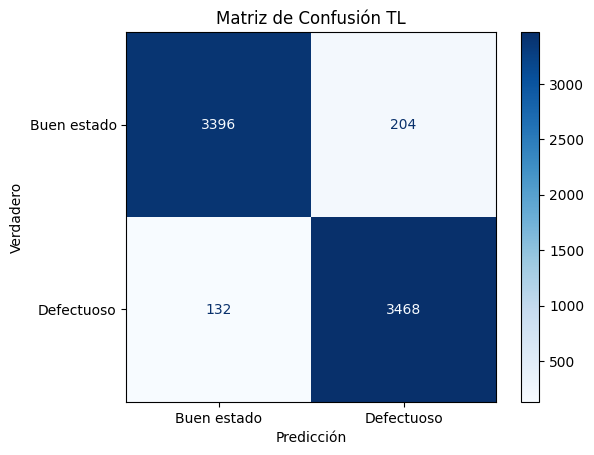

In [ ]:
# crear matriz de confusión
mc = confusion_matrix(y_true_tl, y_pred_tl)

# mostrar matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=mc, display_labels=["Buen estado", "Defectuoso"]
)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.title("Matriz de Confusión TL")
plt.show()

### Ejemplo de generalización con Transfer Learning

---

En está sección se verifica la clasificación del modelo con un número de imágenes al azar.


Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.9535


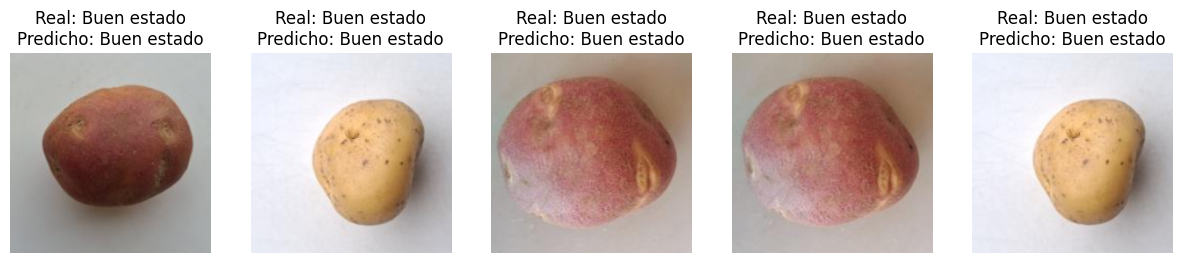

In [ ]:
# múmero de imágenes a mostrar
num_img = 5

# elegir un dataloader aleatorio para obtener la imagen y su etiqueta
for _ in range(random.randint(0, len(test_loader) - 1)):
    imagenes, etiquetas = next(iter(test_loader))

# mover modelos y etiquetas a dispositivo
imagenes, etiquetas = imagenes.to(dispositivo), etiquetas.to(dispositivo)
# cargar modelo
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_TL)
modelo.to(dispositivo)
modelo.eval()

with torch.no_grad():
    salida = modelo(valores_pixel=imagenes)
    predicciones = salida.argmax(dim=1)


def denormalizar(img_tensor):
    media = np.array(MEDIA)
    desv_estandar = np.array(DESV_STD)
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    img = img * desv_estandar + media  # revertir normalización
    img = np.clip(img, 0, 1)  # asegurar rango válido
    return img


# mostrar las primeras 'num_img' imágenes con su predicción
fig, axes = plt.subplots(1, num_img, figsize=(15, 3))

for i in range(num_img):
    img = denormalizar(imagenes[i])  # de Tensor a formato imagen
    etiqueta_verdadera = train_ds.classes[etiquetas[i].cpu()]
    etiqueta_predicha = train_ds.classes[predicciones[i].cpu()]

    axes[i].imshow(img)
    axes[i].set_title(f"Real: {etiqueta_verdadera}\nPredicho: {etiqueta_predicha}")
    axes[i].axis("off")

plt.show()

### Validar generalización del modelo con Transfer Learning

---

En esta sección se verifica la capacidad de generalización del modelo al clasificar imágenes externas al dataset original.


Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.9535


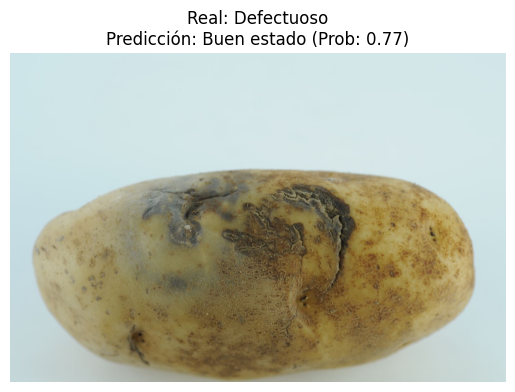

In [ ]:
def transformar_evaluar_img(img, ruta):
    transformar = create_transform(
        input_size=224,
        mean=MEDIA,
        std=DESV_STD,
    )
    imagen_tensor = transformar(img)
    img_tensor = imagen_tensor.unsqueeze(0).to(dispositivo)
    modelo = cargar_checkpoint(modelo_base, ruta)
    modelo.eval()
    with torch.no_grad():
        salida = modelo(valores_pixel=img_tensor)
        pred = salida.argmax(dim=1).item()
        prob = salida.softmax(dim=1)[0][pred].item()

    clases = ["Buen estado", "Defectuoso"]
    eti_real = "Defectuoso"
    return img_tensor, pred, prob, clases, eti_real


img = Image.open("/content/drive/MyDrive/Datos_ViT/img/pod_cha.jpg").convert("RGB")
_, pred, prob, clases, eti_real = transformar_evaluar_img(img, CHECKPOINT_TL)
# mostrar imagen
plt.imshow(img)
plt.axis("off")
plt.title(f"Real: {eti_real}\nPredicción: {clases[pred]} (Prob: {prob:.2f})")
plt.show()

### Eigen-CAMM

---

En esta sección se muestra el mapa de calor que utiliza el modelo para saber a qué parte de la imagen el modelo le presta más atención.


In [ ]:
def transformar_reshape(tensor):
    # eliminar el token CLS (índice 0)
    resultado = tensor[:, 1:, :]
    tamano_grid = int(np.sqrt(resultado.size(1)))
    # reordenar a (batch, canales, grid, grid)
    resultado = resultado.reshape(
        tensor.size(0), tamano_grid, tamano_grid, tensor.size(2)
    )
    return resultado.permute(0, 3, 1, 2)


# función para transformar imagenes
def obtener_transformacion():
    return transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEDIA, std=DESV_STD),
        ]
    )


# función para generar interpretabilidad con Eigen-CAM
def visualizar_eigencam(modelo, ruta_imagen, clase_real=None, dispositivo=None):
    if dispositivo is None:
        dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    imagen_pil = Image.open(ruta_imagen).convert("RGB")
    tensor_imagen = obtener_transformacion()(imagen_pil).unsqueeze(0).to(dispositivo)

    modelo.to(dispositivo)
    modelo.eval()

    # predicción
    with torch.no_grad():
        salida = modelo(tensor_imagen)
        probs = torch.softmax(salida, dim=1).cpu().numpy()[0]
    indice_pred = np.argmax(probs)

    nombres_clases = ["Buen estado", "Defectuoso"]
    etiqueta_predicha = nombres_clases[indice_pred]
    confianza = probs[indice_pred]

    # eigen-cam con el modelo completo
    cam = EigenCAM(
        model=modelo,
        target_layers=[modelo.backbone.blocks[-1].norm1],
        reshape_transform=transformar_reshape,
    )
    mapa_escala_grises = cam(input_tensor=tensor_imagen, targets=None)[0]

    imagen_redimensionada = imagen_pil.resize((224, 224))
    imagen_normalizada = np.float32(imagen_redimensionada) / 255.0
    visualizacion = show_cam_on_image(
        imagen_normalizada, mapa_escala_grises, use_rgb=True
    )

    # visualización
    titulo_real = f"\nReal: {clase_real}" if clase_real else ""
    fig, ejes = plt.subplots(1, 3, figsize=(12, 6))

    ejes[0].imshow(imagen_redimensionada)
    ejes[0].set_title(f"imagen original{titulo_real}", fontsize=12)
    ejes[0].axis("off")

    im = ejes[1].imshow(mapa_escala_grises, cmap="jet")
    ejes[1].set_title(
        f"mapa de calor (EigenCAM)\nclase: {etiqueta_predicha}", fontsize=12
    )
    ejes[1].axis("off")
    plt.colorbar(im, ax=ejes[1], fraction=0.046)

    ejes[2].imshow(visualizacion)
    ejes[2].set_title(
        f"atención del modelo\nPred: {etiqueta_predicha} ({confianza:.2%})",
        fontsize=12,
        fontweight="bold",
    )
    ejes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return etiqueta_predicha, confianza

### Visualizar Eigen-Cam -> Transfer Learning

---

En esta sección se presenta el mapa de calor que refleja las áreas de atención del modelo en la imagen clasificada.


Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/TL/DA-RE/vit_papas_tl.pt
Época: 30
   Mejor métrica: 0.9535


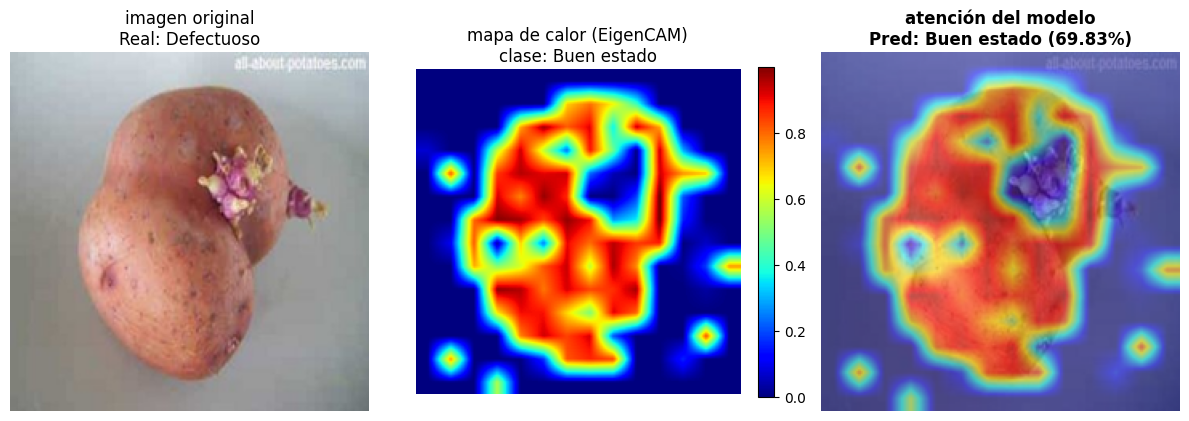

Predicción: Buen estado | Confianza: 69.83% | Correcto: No


In [ ]:
# visualizar Grad-CAM en una imagen de ejemplo
ruta_img = "/content/drive/MyDrive/Datos_ViT/img/p_cho_b.jpg"
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_TL)
etiqueta, confianza = visualizar_eigencam(modelo, ruta_img, "Defectuoso", dispositivo)
print(
    f"Predicción: {etiqueta} | Confianza: {confianza:.2%} | Correcto: {'Sí' if etiqueta == 'Defectuoso' else 'No'}"
)

### Fine-Tuning parcial

---

En esta sección se implementa la técnica del fine-tuning parcial aplicado al modelo base (ViT-Base/16).


In [ ]:
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# inicializar modelo para fine tuning parcial -> capas descongeladas
N_CAPAS_DESCONGELAR = 6
modelo_ftp = ClasificadorPapasViT(
    num_clases=2, capas_descongelar=N_CAPAS_DESCONGELAR
).to(dispositivo)
# parámetros entrenables
entrenables = sum(p.numel() for p in modelo_ftp.parameters() if p.requires_grad)
total = sum(p.numel() for p in modelo_ftp.parameters())
print(
    f"Parámetros entrenables: {entrenables:,} / {total:,} ({100*entrenables/total:.4f}%)"
)
# ====================================
# configuración de FINE-TUNING PARCIAL
# ====================================
config_ftp = ConfigEntrenamiento(
    epocas=20,
    lr=1e-6,
    weight_decay=1e-4,
    batch_size=BATCH_SIZE,
    warmup_frac=0.5,
    mixed_precision=True,
    metrica_principal="f1",
)
# optimizador para fine-tuning
optimizador_ftp = optim.AdamW(
    [p for p in modelo_ftp.parameters() if p.requires_grad],
    lr=config_ftp.lr,
    betas=config_ftp.betas,
    weight_decay=config_ftp.weight_decay,
)
# entrenar capas finales con fine-tuning parcial
historia_ft, mejores_metricas_ft = entrenar_modelo(
    modelo=modelo_ftp,
    train_loader=train_loader,
    val_loader=val_loader,
    criterio_perdida=criterio_perdida,
    optimizador=optimizador_ftp,
    metricas=metricas,
    config=config_ftp,
    ruta_ckpt=CHECKPOINT_FTP,
    dispositivo=dispositivo,
    programador=None,
    escala=escala,
    descripcion=True,
)
# mostrar métricas fine-tuning
display(pd.DataFrame(historia_ft))

Parámetros entrenables: 42,528,770 / 85,800,194 (49.5672%)
Iniciando entrenamiento...

Configuración:
Épocas: 20
Learning Rate: 1e-06
Weight Decay: 0.0001
Batch Size: 32
Mixed Precision: True
Betas: (0.9, 0.999)
Warmup Frac: 0.5
Métrica Principal: f1

Metrica principal f1

Ruta checkpoint: /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt



Época 01/20 | 
Train → perdida: 0.3087 | acc: 0.8647 | f1: 0.8647 | precision: 0.8647 | recall: 0.8647
Val → perdida: 0.0524 | acc: 0.9823 | f1: 0.9823 | precision: 0.9824 | recall: 0.9823
✓ Mejor modelo guardado (época 1) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9823
----------------------------------------------------------------------------------------------------


Época 02/20 | 
Train → perdida: 0.1668 | acc: 0.9296 | f1: 0.9296 | precision: 0.9297 | recall: 0.9296
Val → perdida: 0.0283 | acc: 0.9922 | f1: 0.9922 | precision: 0.9922 | recall: 0.9922
✓ Mejor modelo guardado (época 2) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9922
----------------------------------------------------------------------------------------------------


Época 03/20 | 
Train → perdida: 0.1350 | acc: 0.9421 | f1: 0.9421 | precision: 0.9422 | recall: 0.9421
Val → perdida: 0.0180 | acc: 0.9946 | f1: 0.9946 | precision: 0.9946 | recall: 0.9946
✓ Mejor modelo guardado (época 3) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9946
----------------------------------------------------------------------------------------------------


Época 04/20 | 
Train → perdida: 0.1175 | acc: 0.9505 | f1: 0.9505 | precision: 0.9505 | recall: 0.9505
Val → perdida: 0.0144 | acc: 0.9962 | f1: 0.9962 | precision: 0.9962 | recall: 0.9962
✓ Mejor modelo guardado (época 4) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9962
----------------------------------------------------------------------------------------------------


...

Época 17/20 | 
Train → perdida: 0.0684 | acc: 0.9719 | f1: 0.9719 | precision: 0.9719 | recall: 0.9719
Val → perdida: 0.0027 | acc: 0.9995 | f1: 0.9995 | precision: 0.9995 | recall: 0.9995
✓ Mejor modelo guardado (época 17) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9995
----------------------------------------------------------------------------------------------------


Época 18/20 | 
Train → perdida: 0.0624 | acc: 0.9740 | f1: 0.9740 | precision: 0.9740 | recall: 0.9740
Val → perdida: 0.0023 | acc: 0.9997 | f1: 0.9997 | precision: 0.9997 | recall: 0.9997
✓ Mejor modelo guardado (época 18) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9997
----------------------------------------------------------------------------------------------------


Época 19/20 | 
Train → perdida: 0.0642 | acc: 0.9717 | f1: 0.9717 | precision: 0.9717 | recall: 0.9717
Val → perdida: 0.0022 | acc: 0.9998 | f1: 0.9998 | precision: 0.9998 | recall: 0.9998
✓ Mejor modelo guardado (época 19) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9998
----------------------------------------------------------------------------------------------------


Época 20/20 | 
Train → perdida: 0.0636 | acc: 0.9728 | f1: 0.9728 | precision: 0.9728 | recall: 0.9728
Val → perdida: 0.0022 | acc: 0.9998 | f1: 0.9998 | precision: 0.9998 | recall: 0.9998
✓ Mejor modelo guardado (época 20) → /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
F1-Score: 0.9998
----------------------------------------------------------------------------------------------------
Entrenamiento finalizado.
Mejor f1: 0.9998 (época 20)
Mejor pérdida: 0.002163



,epoca,train_perdida,train_acc,train_f1,train_precision,train_recall,val_perdida,val_acc,val_f1,val_precision,val_recall
0,1,0.308678,0.864670,0.864670,0.864670,0.864670,0.052432,0.982292,0.982291,0.982385,0.982292
1,2,0.166847,0.929644,0.929643,0.929667,0.929644,0.028333,0.992188,0.992188,0.992188,0.992188
2,3,0.134969,0.942144,0.942143,0.942174,0.942144,0.017988,0.994618,0.994618,0.994625,0.994618
3,4,0.117484,0.950521,0.950520,0.950547,0.950521,0.014372,0.996181,0.996181,0.996204,0.996181
4,5,0.105066,0.955859,0.955859,0.955889,0.955859,0.008986,0.997569,0.997569,0.997572,0.997569
5,6,0.099102,0.958160,0.958159,0.958171,0.958160,0.007592,0.998611,0.998611,0.998613,0.998611
6,7,0.091425,0.961415,0.961414,0.961446,0.961415,0.006624,0.998611,0.998611,0.998612,0.998611
7,8,0.092605,0.961154,0.961154,0.961181,0.961154,0.005488,0.998785,0.998785,0.998788,0.998785
8,9,0.086902,0.963194,0.963194,0.963209,0.963194,0.005164,0.999132,0.999132,0.999133,0.999132
9,10,0.081446,0.965017,0.965017,0.965024,0.965017,0.004523,0.998958,0.998958,0.998960,0.998958


### Probar modelo ajustado con Fine-Tuning parcial

---

En esta sección se evalúa el modelo obtenido durante el proceso de fine-tuning parcial, calculando las métricas de pérdida, precisión y F1-Score para medir su rendimiento final.


In [ ]:
modelo = cargar_checkpoint(modelo_ftp, CHECKPOINT_FTP)
# evaluar el modelo fine-tuned en test
metricas_test_ft, y_true_ftp, y_pred_ftp = evaluar_modelo(
    modelo=modelo,
    test_loader=cargar_datos_prueba(test_loader),
    criterio_perdida=criterio_perdida,
    metricas=metricas,
    dispositivo=dispositivo,
    clases=train_ds.classes,
    mixed_precision=config_ftp.mixed_precision,
    detallado=True,
)

mcc = matthews_corrcoef(y_true_ftp, y_pred_ftp)
print(f"MCC: {mcc:.4f}")

# crear DataFrame de métricas test fine-tuning
df_test_ft = pd.DataFrame([{f"test_{k}": v for k, v in metricas_test_ft.items()}])
df_test_ft["test_mcc"] = mcc
display(df_test_ft)

Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
Época: 20
   Mejor métrica: 0.9998



RESULTADOS EN TEST
Perdida: 0.0018
Acc: 0.9994
F1: 0.9994
Precision: 0.9994
Recall: 0.9994

Reporte de Clasificación:
              precision    recall  f1-score   support

 Buen estado       1.00      1.00      1.00      3600
  Defectuoso       1.00      1.00      1.00      3600

    accuracy                           1.00      7200
   macro avg       1.00      1.00      1.00      7200
weighted avg       1.00      1.00      1.00      7200



,test_perdida,test_acc,test_f1,test_precision,test_recall
0,0.001826,0.999444,0.999444,0.999445,0.999444


### Gráficas analíticas

---

En esta sección se presentan las gráficas de pérdida correspondientes al entrenamiento, validación y prueba, con el objetivo de mostrar la evolución del modelo y analizar su desempeño en términos de Precisión y F1-Score durante la aplicación de Fine-Tuning parcial.


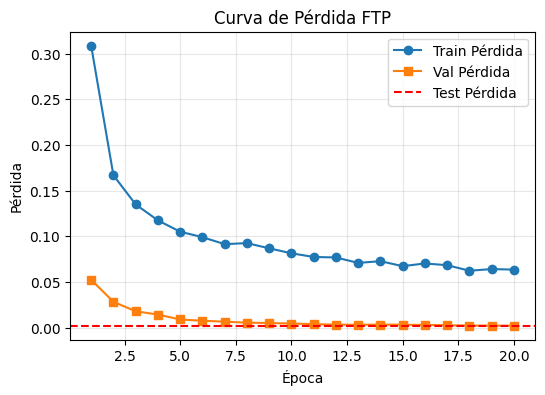

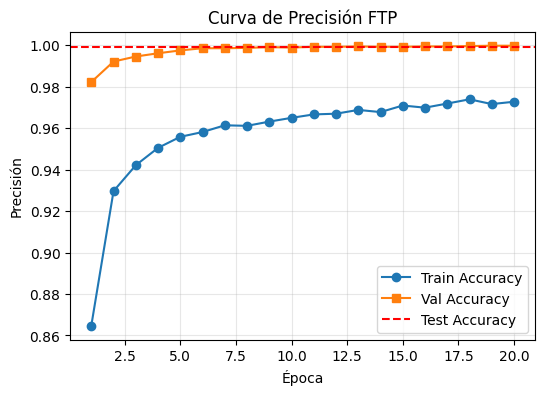

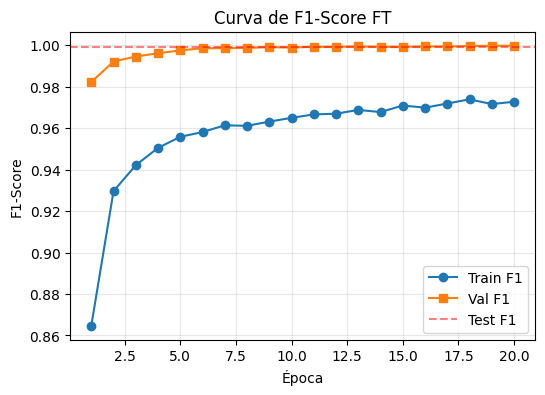

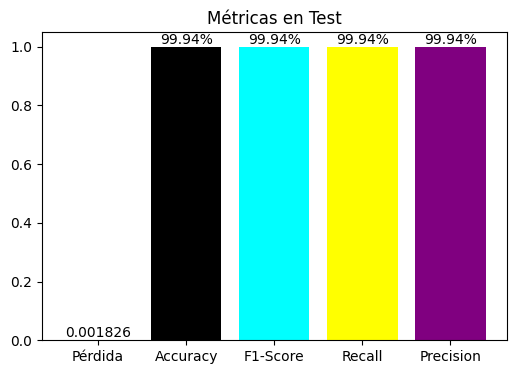

In [ ]:
# asegurar que 'epoca' sea numérica
historia_ft["epoca"] = pd.to_numeric(historia_ft["epoca"], errors="coerce")
historia_ft = historia_ft.dropna(subset=["epoca"])

# gráfica de Pérdida (Train, Val, Test)
plt.figure(figsize=(6, 4))
plt.plot(
    historia_ft.epoca, historia_ft.train_perdida, label="Train Pérdida", marker="o"
)
plt.plot(historia_ft.epoca, historia_ft.val_perdida, label="Val Pérdida", marker="s")
# línea horizontal para test
plt.axhline(
    y=df_test_ft.test_perdida.iloc[0], color="red", linestyle="--", label="Test Pérdida"
)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de Pérdida FTP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# gráfica de Accuracy (Train, Val, Test)
plt.figure(figsize=(6, 4))
plt.plot(historia_ft.epoca, historia_ft.train_acc, label="Train Accuracy", marker="o")
plt.plot(historia_ft.epoca, historia_ft.val_acc, label="Val Accuracy", marker="s")
# línea horizontal para test
plt.axhline(
    y=df_test_ft.test_acc.iloc[0], color="red", linestyle="--", label="Test Accuracy"
)
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.title("Curva de Precisión FTP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# gráfica de F1-Score (Train, Val, Test)
plt.figure(figsize=(6, 4))
plt.plot(historia_ft.epoca, historia_ft.train_f1, label="Train F1", marker="o")
plt.plot(historia_ft.epoca, historia_ft.val_f1, label="Val F1", marker="s")

# línea horizontal para test
plt.axhline(
    y=df_test_ft.test_f1.iloc[0],
    color="red",
    linestyle="--",
    label="Test F1",
    alpha=0.5,
)
plt.xlabel("Época")
plt.ylabel("F1-Score")
plt.title("Curva de F1-Score FT")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
valores = [
    df_test_ft.test_perdida.iloc[0],
    df_test_ft.test_acc.iloc[0],
    df_test_ft.test_f1.iloc[0],
    df_test_ft.test_recall.iloc[0],
    df_test_ft.test_precision.iloc[0],
]
etiq = ["Pérdida", "Accuracy", "F1-Score", "Recall", "Precision"]
barras = plt.bar(etiq, valores, color=["red", "black", "cyan", "yellow", "purple"])
plt.title("Métricas en Test")
# añadir los valores encima de cada barra
for bar, valor, etiqueta in zip(barras, valores, etiq):
    if etiqueta == "Pérdida":
        texto = f"{valor:.6f}"
    else:
        texto = f"{valor*100:.2f}%"
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        bar.get_height(),  # posición y en la altura de la barra
        texto,  # formato del valor
        ha="center",
        va="bottom",  # alineación horizontal y vertical
    )
plt.show()

### Comparar resultados entre Transfer Learning y Fine-Tuning parcial

---

En esta sección se comparan los resultados obtenidos entre el modelo entrenado con Transfer Learning y el modelo entrenado con Fine Tuning parcial, analizando las diferencias en términos de precisión, F1-Score, Recall y Accuracy para evaluar el desempeño de ambas técnicas.


In [ ]:
"""
Compara métricas entre Transfer Learning y Fine-Tuning.
Args:
    df_tl: DataFrame con métricas de Transfer Learning
    df_ft: DataFrame con métricas de Fine-Tuning
    detallado: Imprimir comparación
"""


def comparar_resultados(
    df_tl: pd.DataFrame, df_ft: pd.DataFrame, detallado: bool = True
) -> pd.DataFrame:
    # crear DataFrame de comparación
    comparacion = pd.DataFrame(
        {"Transfer Learning": df_tl.iloc[0], "Fine-Tuning": df_ft.iloc[0]}
    )

    # calcular diferencias
    comparacion["Diferencia"] = (
        comparacion["Fine-Tuning"] - comparacion["Transfer Learning"]
    )
    comparacion["Mejora (%)"] = (
        comparacion["Diferencia"] / comparacion["Transfer Learning"]
    ) * 100

    if detallado:
        print(f"\n{'===='*20}")
        print("COMPARACIÓN: TRANSFER LEARNING vs FINE-TUNING PARCIAL")
        print(f"{'===='*20}\n")

        print(comparacion.round(4).to_string())

        print(f"\n{'===='*20}")
        print("RESUMEN:")
        print(f"{'===='*20}")

        # determinar cuál es mejor
        mejor_modelo = (
            "Fine-Tuning"
            if comparacion.loc["test_f1", "Fine-Tuning"]
            > comparacion.loc["test_f1", "Transfer Learning"]
            else "Transfer Learning"
        )
        print(f"Mejor modelo: {mejor_modelo}")
        print(
            f"Mejora en F1-Score: {comparacion.loc['test_f1', 'Diferencia']:.4f} ({comparacion.loc['test_f1', 'Mejora (%)']:.2f}%)"
        )
        print(f"{'='*70}\n")

    return comparacion


# llamar a la función
comparacion = comparar_resultados(df_test_tl, df_test_ft, detallado=True)
display(comparacion)


COMPARACIÓN: TRANSFER LEARNING vs FINE-TUNING PARCIAL

                Transfer Learning  Fine-Tuning  Diferencia  Mejora (%)
test_perdida               0.1472       0.0018     -0.1454    -98.7600
test_acc                   0.9533       0.9994      0.0461      4.8368
test_f1                    0.9533       0.9994      0.0461      4.8373
test_precision             0.9535       0.9994      0.0459      4.8170
test_recall                0.9533       0.9994      0.0461      4.8368

RESUMEN:
Mejor modelo: Fine-Tuning
Mejora en F1-Score: 0.0461 (4.84%)



,Transfer Learning,Fine-Tuning,Diferencia,Mejora (%)
test_perdida,0.147225,0.001826,-0.145400,-98.759968
test_acc,0.953333,0.999444,0.046111,4.836836
test_f1,0.953329,0.999444,0.046116,4.837341
test_precision,0.953515,0.999445,0.045930,4.816956
test_recall,0.953333,0.999444,0.046111,4.836836


### Gráficas analíticas

En esta sección se visualizan las gráficas correspondientes a las métricas obtenidas mediante transfer learning y fine-tuning parcial.


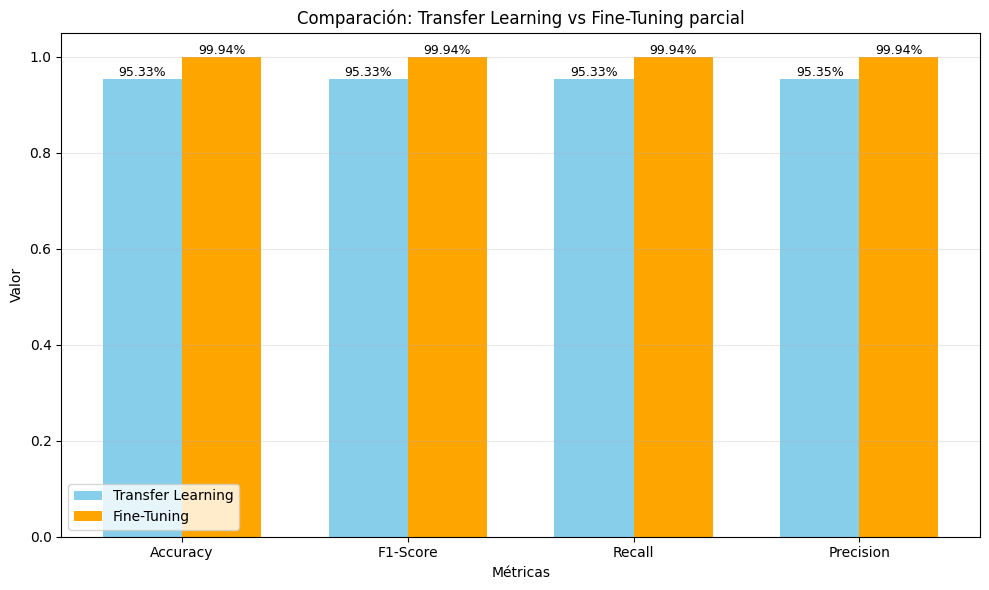

In [ ]:
# gráfica de barras comparativa
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

metricas_nombres = ["Accuracy", "F1-Score", "Recall", "Precision"]
x = np.arange(len(metricas_nombres))
width = 0.35

valores_tl = [
    df_test_tl.test_acc.iloc[0],
    df_test_tl.test_f1.iloc[0],
    df_test_tl.test_recall.iloc[0],
    df_test_tl.test_precision.iloc[0],
]
valores_ft = [
    df_test_ft.test_acc.iloc[0],
    df_test_ft.test_f1.iloc[0],
    df_test_ft.test_recall.iloc[0],
    df_test_ft.test_precision.iloc[0],
]

bars1 = ax.bar(
    x - width / 2, valores_tl, width, label="Transfer Learning", color="skyblue"
)
bars2 = ax.bar(x + width / 2, valores_ft, width, label="Fine-Tuning", color="orange")

# añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height*100:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xlabel("Métricas")
ax.set_ylabel("Valor")
ax.set_title("Comparación: Transfer Learning vs Fine-Tuning parcial")
ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Matriz de confusión

En esta sección se muestra las matrices de confusión para identificar verdaderos positivos y negativos entre las clases de clasificación, tanto con transfer learning como por fine-tuning parcial.


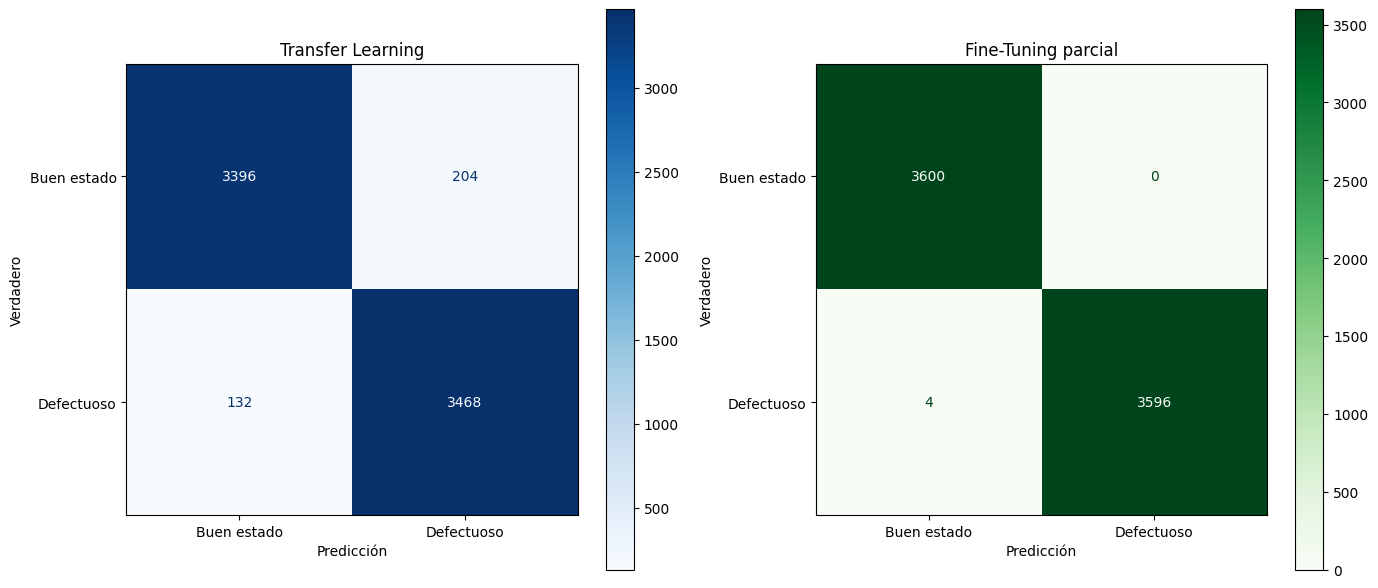

In [ ]:
# crear matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Transfer Learning
mc_tl = confusion_matrix(y_true, y_pred)
disp_tl = ConfusionMatrixDisplay(
    confusion_matrix=mc_tl, display_labels=["Buen estado", "Defectuoso"]
)
disp_tl.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title("Transfer Learning")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Verdadero")

# Fine-Tuning parcial
mc_ft = confusion_matrix(y_true_ftp, y_pred_ftp)
disp_ft = ConfusionMatrixDisplay(
    confusion_matrix=mc_ft, display_labels=["Buen estado", "Defectuoso"]
)
disp_ft.plot(cmap=plt.cm.Greens, ax=axes[1])
axes[1].set_title("Fine-Tuning parcial")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Verdadero")

plt.tight_layout()
plt.show()

### Ejemplo de generalización del modelo con Fine-Tuning parcial

---

En está sección se verifica la clasificación del modelo con un número de imágenes al azar.


Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
Época: 20
   Mejor métrica: 0.9998


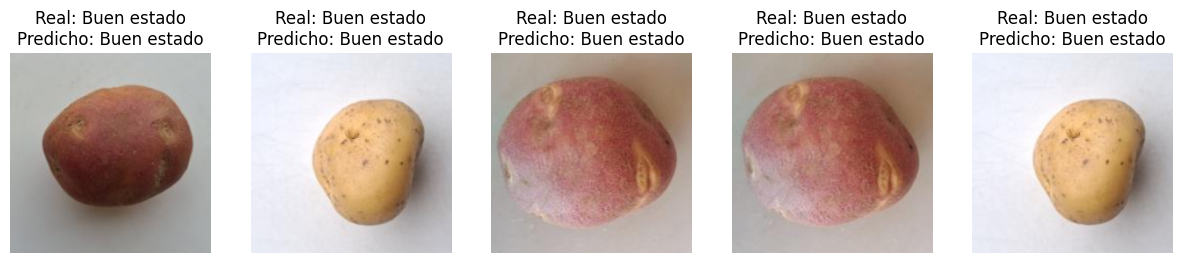

In [ ]:
# múmero de imágenes a mostrar
num_img = 5

# elegir un dataloader aleatorio para obtener la imagen y su etiqueta
for _ in range(random.randint(0, len(test_loader) - 1)):
    imagenes, etiquetas = next(iter(test_loader))

# mover imagenes y etiquetas a dispositivo
imagenes, etiquetas = imagenes.to(dispositivo), etiquetas.to(dispositivo)
# cargar modelo
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_FTP)
modelo.to(dispositivo)
modelo.eval()

with torch.no_grad():
    salida = modelo(valores_pixel=imagenes)
    predicciones = salida.argmax(dim=1)


def denormalizar(img_tensor):
    media = np.array(MEDIA)
    desv_estandar = np.array(DESV_STD)
    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    img = img * desv_estandar + media  # revertir normalización
    img = np.clip(img, 0, 1)  # asegurar rango válido
    return img


# mostrar las primeras 'num_img' imágenes con su predicción
fig, axes = plt.subplots(1, num_img, figsize=(15, 3))

for i in range(num_img):
    img = denormalizar(imagenes[i])  # de Tensor a formato imagen
    etiqueta_verdadera = train_ds.classes[etiquetas[i].cpu()]
    etiqueta_predicha = train_ds.classes[predicciones[i].cpu()]

    axes[i].imshow(img)
    axes[i].set_title(f"Real: {etiqueta_verdadera}\nPredicho: {etiqueta_predicha}")
    axes[i].axis("off")

plt.show()

### Eigen-CAM -> Fine-Tuning parcial

---

Visualizar mapa de atención de la imagen para identificar las áreas que el modelo considera más relevantes para la clasificación con fine-tuning parcial.


Checkpoint cargado: /content/drive/MyDrive/Datos_ViT/checkpoints/FTP/DA-RE/vit_papas_ftp.pt
Época: 20
   Mejor métrica: 0.9998


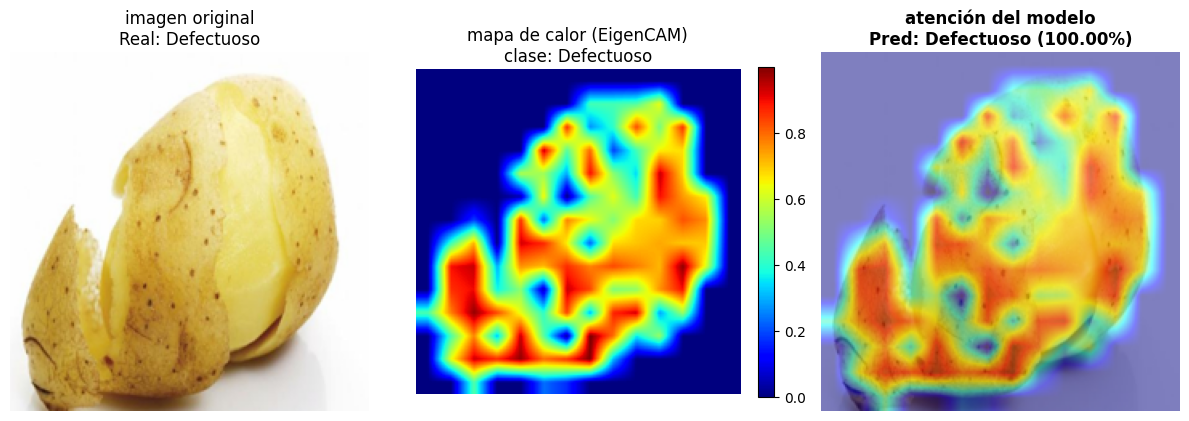

Predicción: Defectuoso | Confianza: 100.00% | Correcto: Sí


In [ ]:
# visualizar Grad-CAM en una imagen de ejemplo
ruta_img = "/content/drive/MyDrive/Datos_ViT/img/mal_cha.jpg"
modelo = cargar_checkpoint(modelo_base, CHECKPOINT_FTP)
etiqueta, confianza = visualizar_eigencam(modelo, ruta_img, "Defectuoso", dispositivo)
print(
    f"Predicción: {etiqueta} | Confianza: {confianza:.2%} | Correcto: {'Sí' if etiqueta == 'Defectuoso' else 'No'}"
)